In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [24]:
#Importing data
df= pd.read_csv("Cleaned_df.csv")
C_df=pd.read_csv("customer_data.csv")

In [25]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPurchase
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [26]:
C_df.head()

,CustomerID,Recency,Frequency,MonetaryValue
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [27]:
X = pd.read_csv("X_features.csv")
X

,Recency,Frequency,MonetaryValue,Cluster
0,326,1,77183.60,4
1,2,7,4310.00,0
2,75,4,1797.24,0
3,19,1,1757.55,0
4,310,1,334.40,2
...,...,...,...,...
4334,278,1,180.60,2
4335,181,1,80.82,1
4336,8,2,178.05,1
4337,4,16,2094.88,1


In [28]:
X['Cluster'] = X['Cluster'].astype('category')

In [29]:
X = pd.get_dummies(X, columns=['Cluster'], drop_first=True)

In [33]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
future_df=df[df["InvoiceDate"]>snapshot_date]

y = future_df.groupby('CustomerID')['TotalPurchase'].sum()
y = y.reindex(X.index, fill_value=0)


In [69]:
zeros = df[df['TotalPurchase'] == 0]
nonzeros = df[df['TotalPurchase'] > 0]

test_zeros   = zeros
test_nonzeros = nonzeros.sample(n=len(zeros), random_state=42)  # same count
test = pd.concat([test_zeros, test_nonzeros])

train = df.drop(test.index)

X_train = train.drop('TotalPurchase', axis=1)
y_train = train['TotalPurchase']
X_test  = test.drop('TotalPurchase', axis=1)
y_test  = test['TotalPurchase']


In [70]:
print((y_test == 0).sum(), "zeros in test set")
print((y_test > 0).sum(), "non-zeros in test set")


40 zeros in test set
40 non-zeros in test set


In [74]:
X_train = X_train.drop(columns=['StockCode', 'Description', 'InvoiceDate', 'Country'])
X_test = X_test.drop(columns=['StockCode', 'Description', 'InvoiceDate', 'Country'])

In [75]:
! pip install xgboost
from sklearn.metrics import mean_squared_error
import xgboost as xgb 


In [76]:
model= xgb.XGBRegressor(n_estimator=300,learning_rate=0.5,max_depth=4, sub_sample=0.8,colsample_bytree=0.8,random_state=42)
model.fit(X_train,y_train)

c:\Users\bhave\sample_project_2\env\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:04:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "n_estimator", "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.5, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimator=300,
             n_estimators=None, n_jobs=None, ...)

In [77]:
y_pred=model.predict(X_test)

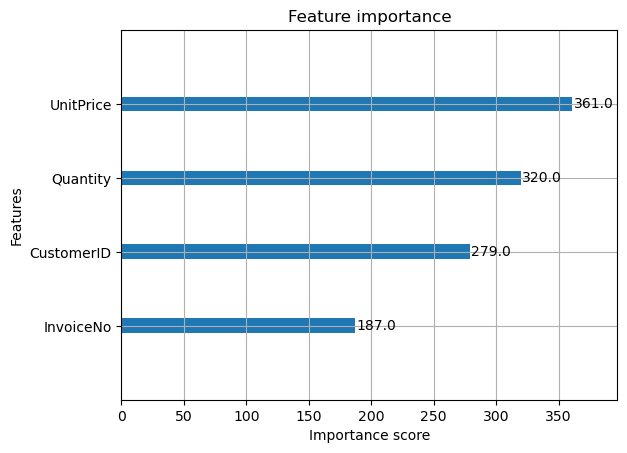

In [87]:
from xgboost import plot_importance
plot_importance(model, importance_type='weight') 
plt.show()

In [78]:
rmse =np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 177.04439164838064


In [80]:
print(y_test.head())
print(y_pred[:5])

6914     0.0
22539    0.0
25379    0.0
29080    0.0
29082    0.0
Name: TotalPurchase, dtype: float64
[14.408466 -1.435804  6.580788 21.902287 21.902287]


In [81]:
df['TotalPurchase'].describe()

count    397924.000000
mean         22.394749
std         309.055588
min           0.000000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalPurchase, dtype: float64

In [82]:
print(df['TotalPurchase'].dtype)

float64


In [83]:
print(df['TotalPurchase'].dtype)
print(df['TotalPurchase'].describe())

float64
count    397924.000000
mean         22.394749
std         309.055588
min           0.000000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalPurchase, dtype: float64


In [84]:
if 'TotalPurchase' in X.columns:
    print("DATA LEAKAGE: Target variable in features!")

In [85]:
print("First 10 actual values:", y_test.values[:10])
print("First 10 predictions:", y_pred[:10])

First 10 actual values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 10 predictions: [14.408466  -1.435804   6.580788  21.902287  21.902287  -5.986814
 10.1070795  1.9385635  3.0765216 -9.141209 ]


In [54]:
print("Percentage of zero purchases:", (df['TotalPurchase'] == 0).mean() * 100)
print("Value counts of TotalPurchase:")
print(df['TotalPurchase'].value_counts().head(10))

Percentage of zero purchases: 0.010052170766276977
Value counts of TotalPurchase:
TotalPurchase
15.00    20082
19.80    11033
17.70     9174
16.50     8490
10.20     8028
1.25      7552
3.75      6847
1.65      6228
10.50     5550
20.80     5524
Name: count, dtype: int64


In [86]:
print("Total rows:", len(df))
print("Rows with TotalPurchase = 0:", (df['TotalPurchase'] == 0).sum())
print("Rows with TotalPurchase > 0:", (df['TotalPurchase'] > 0).sum())


Total rows: 397924
Rows with TotalPurchase = 0: 40
Rows with TotalPurchase > 0: 397884


In [68]:
print((y_test == 0).sum(), "zeros in test set")
print((y_test > 0).sum(), "non-zeros in test set")


40 zeros in test set
0 non-zeros in test set
